# Compare non-linear P(k) with public emulators

- DarkEmulator2 total non-linear P(k) is compared against public emulators.
- Cosmologies are drawn from the overlap of DQ2 and target-emulator ranges.
- Each target section defines parameter conversion and validity cuts.

## Optional dependencies

```bash
cd /path/to/your/working/directory

pip install euclidemu2 baccoemu gokunemu AletheiaCosmo

# Aemulus
pip install velocileptors
python -m pip install -v git+https://github.com/AemulusProject/Aemulator.git
python -m pip install -v git+https://github.com/AemulusProject/aemulus_heft.git

# CSSTemu
pip install git+https://github.com/czymh/csstemu

# Mira-Titan IV / CosmicEmu
git clone https://github.com/lanl/CosmicEmu.git
cd CosmicEmu/2022-Mira-Titan-IV/P_tot
make
```

In [1]:
from pathlib import Path

MTU_DIR = Path("~/software/src/python/CosmicEmu").expanduser()
#MTU_DIR = Path("./CosmicEmu")


## Common settings

- `N_COSMO`, `SEED`, `REDSHIFTS`, and `KLIST` define the comparison grid.
- `sample_params_for()` samples the DQ2-target overlap range.
- `flags` disable target-unsupported dimensions such as curvature or `wa`.
- `valid_*()` applies additional target-specific cuts.

In [2]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from dark_emulator2 import DarkEmulator2

In [3]:
N_COSMO = 20
SEED = 10
REDSHIFTS = np.array([0.0, 0.5, 1.0])
KLIST = np.logspace(-2, 1, 201)

In [4]:
def sample_params_for(preset, flags, valid=None, n=N_COSMO, seed=SEED, max_try=100000):
    random.seed(seed)
    np.random.seed(seed)
    emu = DarkEmulator2()
    range_dict = emu.param.get_preset_range_dict_pair("preset_de2", preset)
    params = []
    ntry = 0

    with tqdm(total=n, desc=f"sample {preset}") as pbar:
        while len(params) < n:
            ntry += 1
            if ntry > max_try:
                raise RuntimeError(f"Only {len(params)} valid cosmologies were found for {preset} after {max_try} tries.")

            p = emu.param.rand_param_cosmology(range_dict=range_dict, **flags)
            if not flags.get("nu", True):
                p["Mnu"] = 0.0
                p["Omega_nu"] = 0.0
            else:
                p["Omega_nu"] = p["Mnu"] / (93.14 * p["h0"]**2)
            emu.param.clear_As(p)
            emu.param.clear_lnAs(p)
            p["As"] = emu.get_As(p)
            p["dist"] = emu.get_power_distance(p)

            if "As" in range_dict and not (range_dict["As"][0] <= p["As"] <= range_dict["As"][1]):
                continue
            if valid is not None and not valid(p, emu):
                continue

            params.append(p)
            pbar.update(1)
            pbar.set_postfix(tries=ntry)

    return sorted(params, key=lambda q: q["dist"])

In [5]:
def run_de2(params, redshifts=REDSHIFTS, klist=KLIST):
    emu = DarkEmulator2()
    pk = []
    for p in tqdm(params, desc="DE2"):
        k, y = emu.get_pk_total(p, zred=redshifts, klist=klist, method="emulator")
        pk.append(y)
    return k, np.asarray(pk)

In [6]:
def plot_comparison(result, iz=None):
    ncosmo = len(result["params"])
    z_indices = list(range(len(REDSHIFTS))) if iz is None else [iz]
    nz = len(z_indices)

    kd = np.asarray(result["k_de2"])
    k_tgt = np.asarray(result["k_tgt"])
    pk_de2 = np.asarray(result["pk_de2"])
    pk_tgt = np.asarray(result["pk_tgt"])
    colors = plt.cm.jet(np.linspace(0.05, 0.95, ncosmo))
    fig, axes = plt.subplots(2, nz, figsize=(4.0 * nz, 6.2), sharex="col", height_ratios=[2, 1], squeeze=False)

    for col, iz_now in enumerate(z_indices):
        if pk_de2.ndim == 3 and pk_de2.shape[0] == ncosmo:
            pd = pk_de2[:, iz_now, :]
        elif pk_de2.ndim == 3 and pk_de2.shape[1] == ncosmo:
            pd = pk_de2[iz_now, :, :]
        else:
            pd = pk_de2

        if pk_tgt.ndim == 3 and pk_tgt.shape[0] == ncosmo:
            pt = pk_tgt[:, iz_now, :]
        elif pk_tgt.ndim == 3 and pk_tgt.shape[1] == ncosmo:
            pt = pk_tgt[iz_now, :, :]
        else:
            pt = pk_tgt

        ax0, ax1 = axes[0, col], axes[1, col]
        for i, color in enumerate(colors):
            kt = k_tgt[i] if k_tgt.ndim == 2 else k_tgt
            ok_t = (kt >= kd.min()) & (kt <= kd.max()) & (pt[i] > 0)
            ok_d = pd[i] > 0
            de2_on_tgt = np.exp(np.interp(np.log(kt[ok_t]), np.log(kd[ok_d]), np.log(pd[i][ok_d])))
            ax0.loglog(kd, pd[i], "--", color=color, lw=0.8, alpha=0.65)
            ax0.loglog(kt[ok_t], pt[i][ok_t], "-", color=color, lw=0.8, alpha=0.65)
            ax1.semilogx(kt[ok_t], pt[i][ok_t] / de2_on_tgt, "-", color=color, lw=0.8, alpha=0.8)

        ax0.set_title(f"z = {REDSHIFTS[iz_now]:.2f}")
        ax0.grid(True, which="both", alpha=0.3)
        ax1.axhline(1.0, color="0.2", lw=0.8)
        ax1.axhline(0.95, color="0.4", lw=0.7, ls=":")
        ax1.axhline(1.05, color="0.4", lw=0.7, ls=":")
        ax1.set_ylim(0.9, 1.1)
        ax1.grid(True, which="both", alpha=0.3)
        ax1.set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
        if col == 0:
            ax0.plot([], [], "k--", label="DarkEmulator2")
            ax0.plot([], [], "k-", label=result["label"])
            ax0.set_ylabel(r"$P_\mathrm{nl}(k)$")
            ax1.set_ylabel(f"{result['label']} / DE2")
            ax0.legend(fontsize="small")

    fig.suptitle(f"{result['label']} vs DarkEmulator2, {ncosmo} cosmologies")
    fig.tight_layout()

## EuclidEmulator2

In [ ]:
import euclidemu2 as ee2

def to_ee2(p):
    return dict(As=p["As"], ns=p["ns"], Omb=p["omega_b"] / p["h0"]**2, Omm=p["Omega_m"], h=p["h0"], mnu=p["Mnu"], w0=p["w0"], wa=p["wa"])


def valid_ee2(p, emu):
    return 0.04 <= to_ee2(p)["Omb"] <= 0.06


ee2_params = sample_params_for("preset_ee2", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_ee2)
print(f"{len(ee2_params)} cosmologies selected for DE2 vs EuclidEmulator2.")

In [ ]:
def run_ee2(params, redshifts, klist):
    emu = ee2.PyEuclidEmulator()
    pk = []
    for p in tqdm(params, desc="EE2"):
        k, pnl, _, _ = emu.get_pnonlin(to_ee2(p), redshifts)
        pk.append(np.asarray(list(pnl.values())))
    return k, np.asarray(pk)

t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(ee2_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_ee2, pk_ee2 = run_ee2(ee2_params, REDSHIFTS, KLIST)
ee2_time = time.perf_counter() - t0

ee2_result = dict(label="EuclidEmulator2", params=ee2_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_ee2, pk_tgt=pk_ee2)

print(f"DE2: {de2_time:.2f} sec")
print(f"EuclidEmulator2: {ee2_time:.2f} sec")

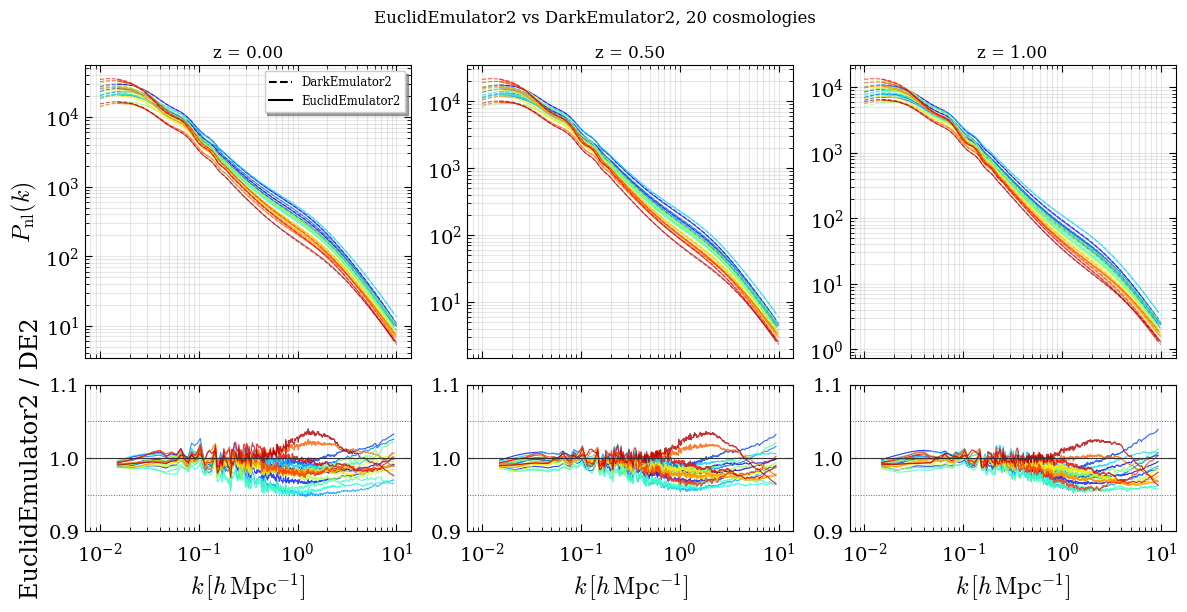

In [9]:
plot_comparison(ee2_result)

## BACCOemu

In [ ]:
import baccoemu as bce
bacco_sigma8_emu = bce.Matter_powerspectrum(verbose=False)

def to_bacco(p):
    return dict(A_s=p["As"], ns=p["ns"], omega_baryon=p["omega_b"] / p["h0"]**2, omega_cold=p["Omega_m"] - p["Omega_nu"], hubble=p["h0"], neutrino_mass=p["Mnu"], w0=p["w0"], wa=p["wa"])


def valid_bacco(p, emu):
    b = to_bacco(p)
    if not (0.04 <= b["omega_baryon"] <= 0.06 and 0.23 <= b["omega_cold"] <= 0.40):
        return False
    return 0.73 <= bacco_sigma8_emu.get_sigma8(**b) <= 0.9


bacco_params = sample_params_for("preset_bacco", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_bacco)
print(f"{len(bacco_params)} cosmologies selected for DE2 vs BACCOemu.")

In [ ]:
def run_bacco(params, redshifts, klist):
    emu = bce.Matter_powerspectrum(verbose=False)
    k = emu.emulator["nonlinear"]["k"]
    pk = []
    for p in tqdm(params, desc="BACCO"):
        bcep = to_bacco(p)
        pk.append([emu.get_nonlinear_pk(k=k, cold=False, expfactor=1.0 / (1.0 + z), **bcep)[1] for z in redshifts])
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(bacco_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_bacco, pk_bacco = run_bacco(bacco_params, REDSHIFTS, KLIST)
bacco_time = time.perf_counter() - t0

bacco_result = dict(label="BACCOemu", params=bacco_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_bacco, pk_tgt=pk_bacco)
print(f"DE2: {de2_time:.2f} sec")
print(f"BACCOemu: {bacco_time:.2f} sec")

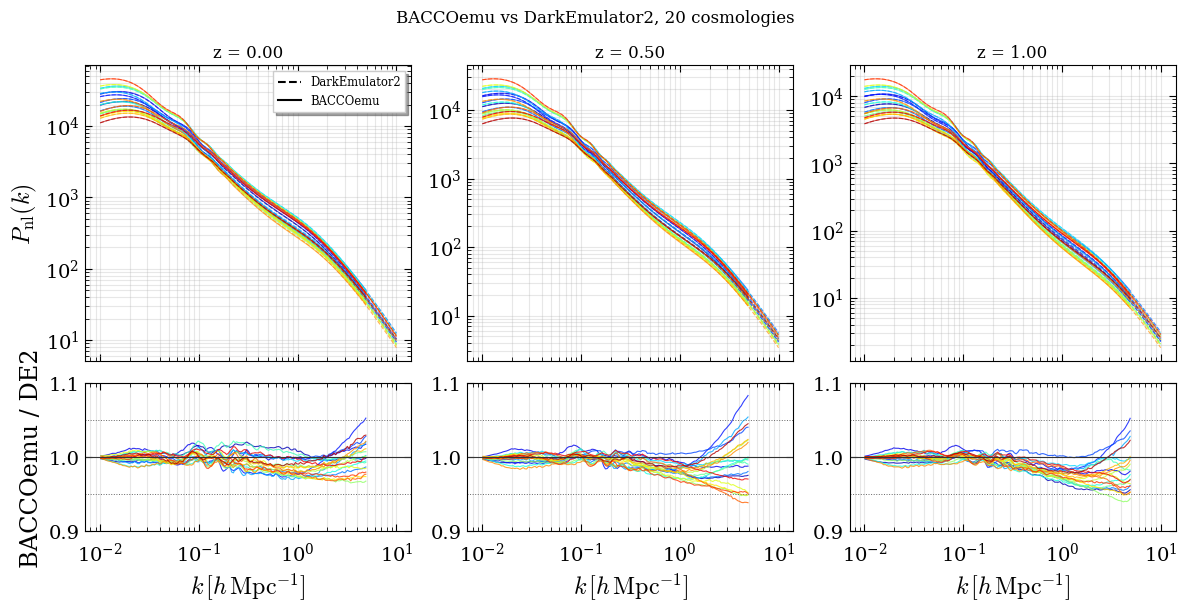

In [12]:
plot_comparison(bacco_result)

## Aemulus

In [ ]:
from aemulus_heft.heft_emu import HEFTEmulator
from aemulus_heft.utils import lpt_spectra

def to_aemulus(p):
    return dict(omega_b=p["omega_b"], omega_cdm=p["omega_cdm"], As=p["As"], h0=p["h0"], w0=p["w0"], ns=p["ns"], Mnu=p["Mnu"])

aemulus_params = sample_params_for("preset_aemulus", flags=dict(nu=True, w0=True, wa=False, K=False))
print(f"{len(aemulus_params)} cosmologies selected for DE2 vs Aemulus.")

In [ ]:
def run_aemulus(params, redshifts, klist):
    emu = HEFTEmulator()
    k = klist[klist < 4.0]
    pk = []
    for p in tqdm(params, desc="Aemulus"):
        a = to_aemulus(p)
        aemup = [a["omega_b"], a["omega_cdm"], a["w0"], a["ns"], a["As"] * 1e9, 100 * a["h0"], min(0.49, a["Mnu"])]
        row = []
        for z in redshifts:
            spec_lpt, sigma8z = lpt_spectra(k, z, aemup)
            row.append(emu.predict(k, np.asarray(aemup + [sigma8z]), spec_lpt)[0])
        pk.append(row)
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(aemulus_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_aemulus, pk_aemulus = run_aemulus(aemulus_params, REDSHIFTS, KLIST)
aemulus_time = time.perf_counter() - t0

aemulus_result = dict(label="Aemulus", params=aemulus_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_aemulus, pk_tgt=pk_aemulus)
print(f"DE2: {de2_time:.2f} sec")
print(f"Aemulus: {aemulus_time:.2f} sec")

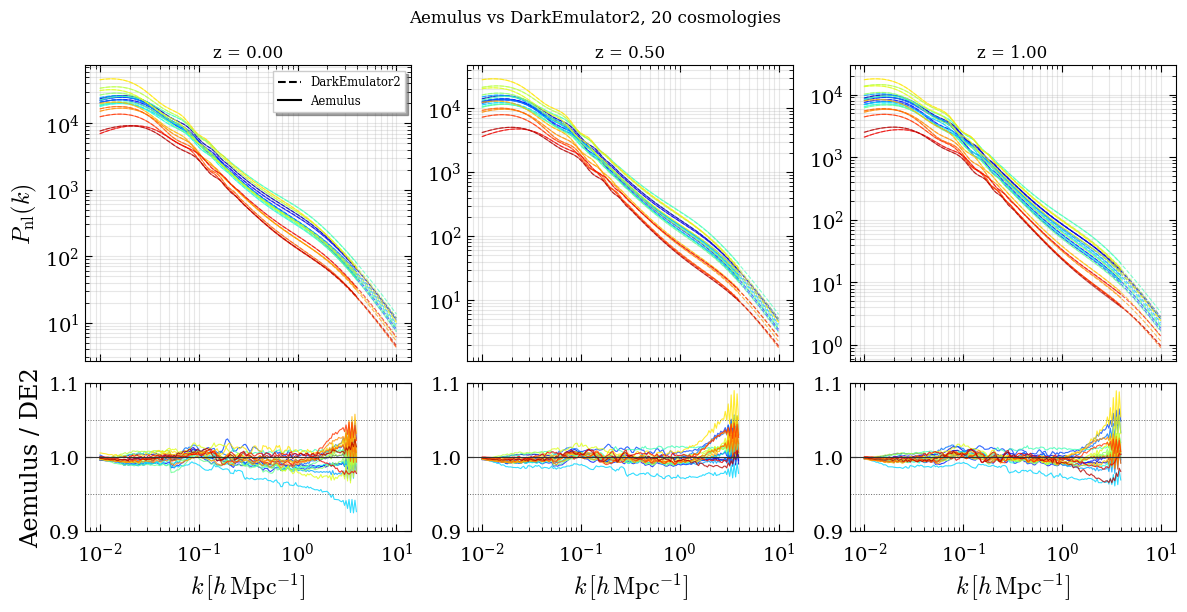

In [15]:
plot_comparison(aemulus_result)

## Mira-Titan IV

In [16]:
import os
import subprocess

def to_mtu(p):
    wsum = -(p["w0"] + p["wa"])
    return dict(omega_m=p["Omega_m"] * p["h0"]**2, sigma8=p["sigma8"], omega_b=p["omega_b"], ns=p["ns"], h=p["h0"], omega_nu=p["Omega_nu"] * p["h0"]**2, w0=p["w0"], wa=p["wa"], w0wa4=wsum**0.25 if wsum > 0 else np.nan)


def valid_mtu(p, emu):
    m = to_mtu(p)
    return 0.120 <= m["omega_m"] <= 0.155 and 0.0 <= m["omega_nu"] <= 0.01 and 0.3 <= m["w0wa4"] <= 1.29


mtu_params = sample_params_for("preset_mtu", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_mtu)
print(f"{len(mtu_params)} cosmologies selected for DE2 vs Mira-Titan IV.")

20 cosmologies selected for DE2 vs Mira-Titan IV.


In [17]:
def run_mtu(params, redshifts, klist):
    run_dir = Path.cwd()
    os.chdir(MTU_DIR)
    try:
        lines = []
        for p in params:
            m = to_mtu(p)
            sigma8 = min(max(m["sigma8"], 0.700001), 0.899999)
            for z in redshifts:
                lines.append(f"{m['omega_m']:.6f} {m['omega_b']:.6f} {sigma8:.6f} {m['h']:.6f} {m['ns']:.6f} {m['w0']:.6f} {m['wa']:.6f} {m['omega_nu']:.6f} {z:.6f}")
        Path("xstar.dat").write_text("\n".join(lines) + "\n")
        subprocess.call("./2022-Mira-Titan-IV/P_tot/emu.exe")
        all_k, all_pk = [], []
        for ip, p in enumerate(tqdm(params, desc="MTU")):
            row = []
            for iz in range(len(redshifts)):
                k, y = np.loadtxt(f"EMU{ip * len(redshifts) + iz:d}.txt", unpack=True)
                Path(f"EMU{ip * len(redshifts) + iz:d}.txt").unlink()
                row.append(y * p["h0"]**3)
            all_k.append(k / p["h0"])
            all_pk.append(row)
        return np.asarray(all_k), np.asarray(all_pk)
    finally:
        os.chdir(run_dir)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(mtu_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_mtu, pk_mtu = run_mtu(mtu_params, REDSHIFTS, KLIST)
mtu_time = time.perf_counter() - t0

mtu_result = dict(label="Mira-Titan IV", params=mtu_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_mtu, pk_tgt=pk_mtu)
print(f"DE2: {de2_time:.2f} sec")
print(f"Mira-Titan IV: {mtu_time:.2f} sec")

DE2: 1.51 sec
Mira-Titan IV: 0.38 sec


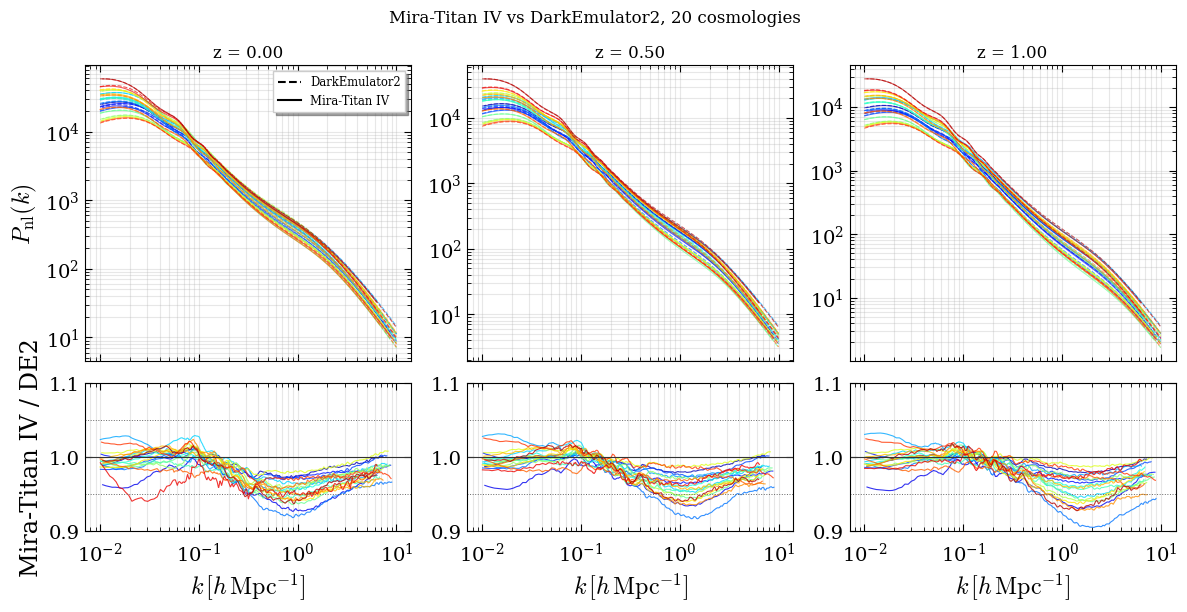

In [18]:
plot_comparison(mtu_result)

## GokuNEmu

In [19]:
from gokunemu import MatterPowerEmulator

def to_goku(p):
    return dict(Omega_m=p["Omega_m"], Omega_b=p["omega_b"] / p["h0"]**2, h0=p["h0"], As=p["As"], ns=p["ns"], Mnu=p["Mnu"], w0=p["w0"], wa=p["wa"], Neff=3.044, alpha_s=0.0)


def valid_goku(p, emu):
    return 0.040 <= to_goku(p)["Omega_b"] <= 0.055


goku_params = sample_params_for("preset_goku", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_goku)
print(f"{len(goku_params)} cosmologies selected for DE2 vs GokuNEmu.")

20 cosmologies selected for DE2 vs GokuNEmu.


In [20]:
def run_goku(params, redshifts, klist):
    emu = MatterPowerEmulator()
    order = ["Omega_m", "Omega_b", "h0", "As", "ns", "w0", "wa", "Mnu", "Neff", "alpha_s"]
    cosmo = np.asarray([[to_goku(p)[key] for key in order] for p in params])
    k, pk = emu.get_matter_power(cosmo, redshifts=redshifts)
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(goku_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_goku, pk_goku = run_goku(goku_params, REDSHIFTS, KLIST)
goku_time = time.perf_counter() - t0

goku_result = dict(label="GokuNEmu", params=goku_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_goku, pk_tgt=pk_goku)
print(f"DE2: {de2_time:.2f} sec")
print(f"GokuNEmu: {goku_time:.2f} sec")

DE2: 1.75 sec
GokuNEmu: 0.47 sec


### Plot

- Dashed lines: DarkEmulator2.
- Solid lines: target emulator.
- Lower panels show target / DarkEmulator2.

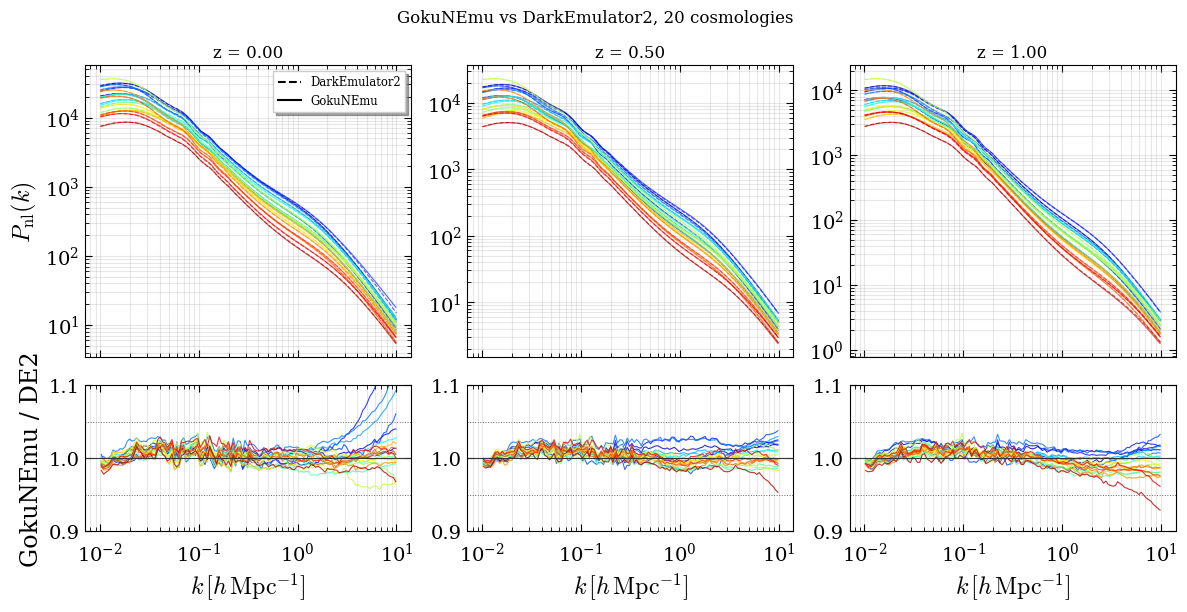

In [21]:
plot_comparison(goku_result)

## Aletheia

In [22]:
from aletheiacosmo import AletheiaEmu
from aletheiacosmo.cosmology import Cosmology as AletheiaCosmo

aletheia_check = AletheiaEmu()

def to_aletheia(p):
    h = p["h0"]
    omega_k = p["Omega_k"] * h**2
    omega_de = h**2 - p["omega_cdm"] - p["omega_b"] - omega_k
    return dict(A_s=p["As"], n_s=p["ns"], omega_b=p["omega_b"], omega_c=p["omega_cdm"], h=h, omega_nu=0.0, w_0=p["w0"], w_a=p["wa"], omega_k=omega_k, omega_de=omega_de)


def valid_aletheia(p, emu):
    a = to_aletheia(p)
    if not (0.3000 * 0.925 < a["omega_de"] < 0.3000 * 1.125):
        return False
    if emu.param.check_planck_sigma(p) > 5.0:
        return False
    cosmo = AletheiaCosmo(a)
    try:
        aletheia_check._validate_params(a, cosmo.get_sigma12(0.0))
        aletheia_check._validate_params(a, cosmo.get_sigma12(3.0))
    except ValueError:
        return False
    return True


aletheia_params = sample_params_for("preset_aletheia", flags=dict(nu=False, w0=True, wa=True, K=False), valid=valid_aletheia)
print(f"{len(aletheia_params)} cosmologies selected for DE2 vs Aletheia.")

/home/stanaka/venv/lib/python3.10/site-packages/aletheiacosmo/growth.py:107: RuntimeWarning: overflow encountered in exp
  a = np.exp(x)  # Convert x = ln(a) to a
/home/stanaka/venv/lib/python3.10/site-packages/aletheiacosmo/growth.py:144: RuntimeWarning: invalid value encountered in scalar divide
  self.w0 + self.wa * (1.0 + (1.0 - a) / np.log(a))
/home/stanaka/venv/lib/python3.10/site-packages/aletheiacosmo/growth.py:148: RuntimeWarning: invalid value encountered in scalar multiply
  arg = 187000.0 * a * self.onuh2
/home/stanaka/venv/lib/python3.10/site-packages/aletheiacosmo/growth.py:118: RuntimeWarning: invalid value encountered in scalar divide
  self.w0 + self.wa * (1.0 + (1.0 - a) / np.log(a))
/home/stanaka/venv/lib/python3.10/site-packages/aletheiacosmo/growth.py:151: RuntimeWarning: divide by zero encountered in scalar divide
  self.ode0 / a**(3 * (1 + w_eff)) +
/home/stanaka/venv/lib/python3.10/site-packages/aletheiacosmo/growth.py:152: RuntimeWarning: overflow encountered i

20 cosmologies selected for DE2 vs Aletheia.


In [ ]:
def run_aletheia(params, redshifts, klist):
    emu = AletheiaEmu()
    k_nl = np.logspace(-2.22, np.log10(2.0), 200)
    all_k, all_pk = [], []
    for p in tqdm(params, desc="Aletheia"):
        values = to_aletheia(p)
        all_k.append(k_nl / p["h0"])
        all_pk.append([emu.get_pnl(k_nl, values, z) * p["h0"]**3 for z in redshifts])
    return np.asarray(all_k), np.asarray(all_pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(aletheia_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_aletheia, pk_aletheia = run_aletheia(aletheia_params, REDSHIFTS, KLIST)
aletheia_time = time.perf_counter() - t0

aletheia_result = dict(label="Aletheia", params=aletheia_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_aletheia, pk_tgt=pk_aletheia)
print(f"DE2: {de2_time:.2f} sec")
print(f"Aletheia: {aletheia_time:.2f} sec")

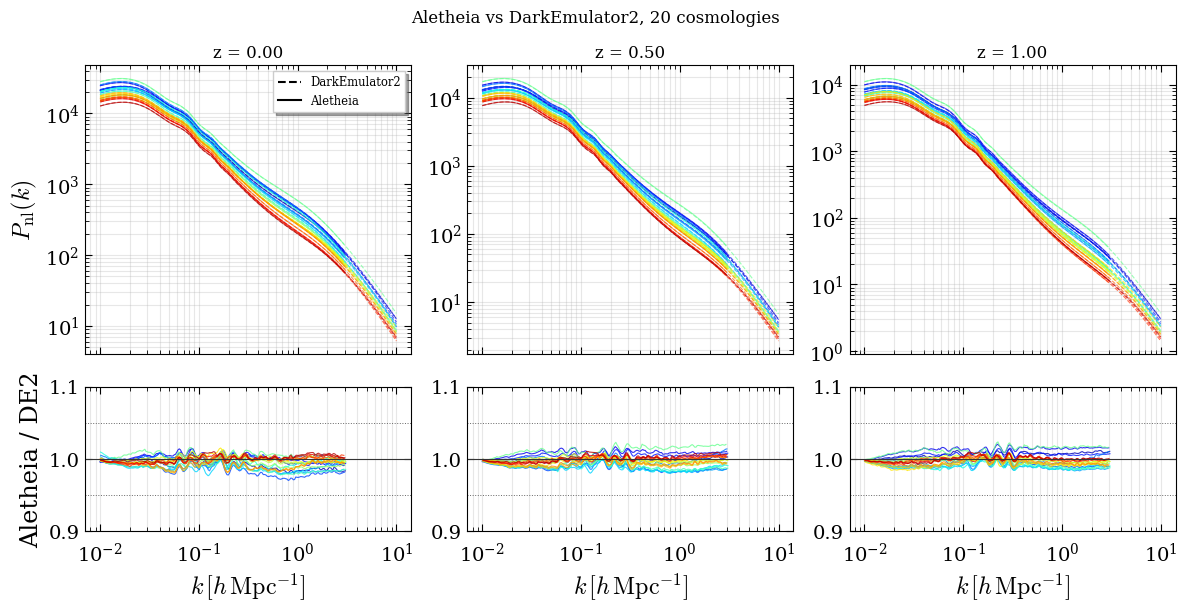

In [24]:
plot_comparison(aletheia_result)

## CSSTemu

In [25]:
from CEmulator.Emulator import Pkmm_CEmulator


# Use "single" to compare with the native CSSTemu training convention.
CSSTEMU_NEUTRINO_MASS_SPLIT = "degenerate"


def to_csstemu(p):
    Omegab = p["omega_b"] / p["h0"]**2
    Omeganu = p.get("Omega_nu", p["Mnu"] / (93.14 * p["h0"]**2))
    Omegac = p["Omega_m"] - Omeganu - Omegab
    return dict(Omegab=Omegab, Omegac=Omegac, H0=100.0 * p["h0"], As=p["As"], ns=p["ns"], w=p["w0"], wa=p["wa"], mnu=p["Mnu"])


def valid_csstemu(p, emu):
    c = to_csstemu(p)
    Omegacb = c["Omegab"] + c["Omegac"]
    return 0.04 <= c["Omegab"] <= 0.06 and 0.24 <= Omegacb <= 0.40 and c["Omegac"] > 0.0


csstemu_params = sample_params_for("preset_csstemu", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_csstemu)
print(f"{len(csstemu_params)} cosmologies selected for DE2 vs CSSTemu.")

20 cosmologies selected for DE2 vs CSSTemu.


In [26]:
def run_csstemu(params, redshifts, klist):
    emu = Pkmm_CEmulator(neutrino_mass_split=CSSTEMU_NEUTRINO_MASS_SPLIT)
    pk = []
    for p in tqdm(params, desc="CSSTemu"):
        emu.set_cosmos(**to_csstemu(p))
        # CSSTemu documents hmcode2020 as the default nonlinear baseline for get_pknl.
        pk.append(emu.get_pknl(z=redshifts, k=klist, Pcb=False, lintype="Emulator", nltype="hmcode2020"))
    return klist, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(csstemu_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_csstemu, pk_csstemu = run_csstemu(csstemu_params, REDSHIFTS, KLIST)
csstemu_time = time.perf_counter() - t0

csstemu_result = dict(label="CSSTemu", params=csstemu_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_csstemu, pk_tgt=pk_csstemu)
print(f"DE2: {de2_time:.2f} sec")
print(f"CSSTemu: {csstemu_time:.2f} sec")

DE2: 0.96 sec
CSSTemu: 4.52 sec


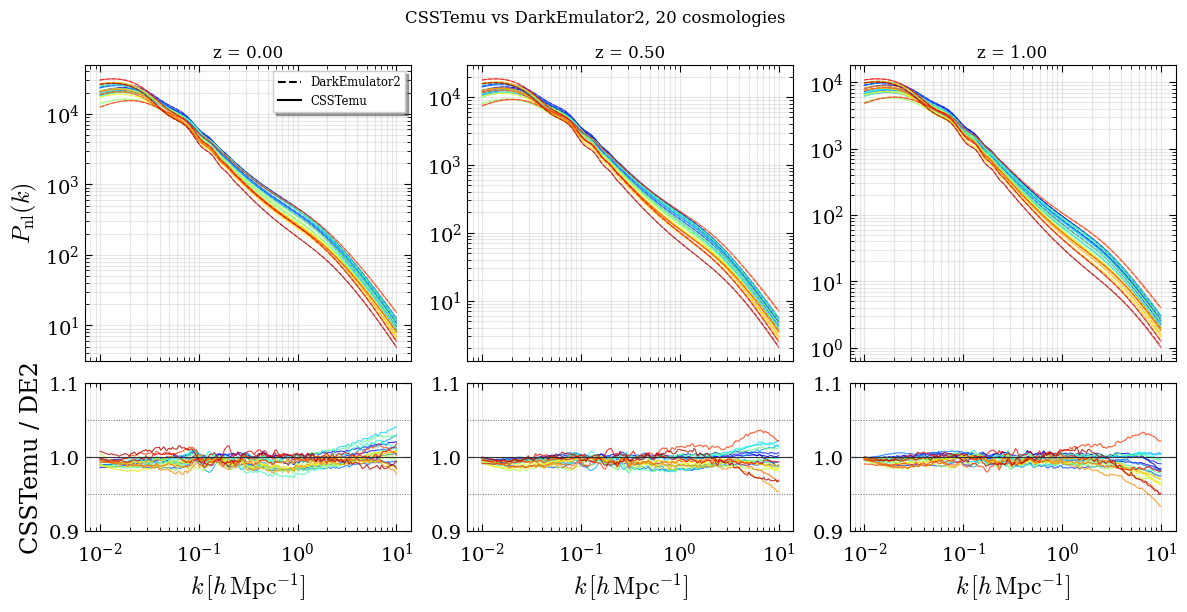

In [27]:
plot_comparison(csstemu_result)